# Enviroment Required

Python Version: Python 3.7 or later (recommended)

Required Libraries: pandas, numpy, matplotlib, seaborn, fancyimpute, scikit-learn, statsmodels, scipy

Need install all these libraries before load them.


## Load Libraries


In [2]:
# load libraries
# these libraries need installed before loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fancyimpute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import spearmanr

# Data ingestion and cleaning

## Read Data

In [3]:
# read data from csv file
df = pd.read_csv('diabetes_diagnosis.csv')
# check data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264802 entries, 0 to 264801
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            264802 non-null  int64  
 1   CholCheck             113865 non-null  float64
 2   BMI                   177418 non-null  float64
 3   Smoker                145642 non-null  float64
 4   Stroke                105921 non-null  float64
 5   HeartDiseaseorAttack  193306 non-null  float64
 6   PhysActivity          76793 non-null   float64
 7   Fruits                103273 non-null  float64
 8   Veggies               95329 non-null   float64
 9   AnyHealthcare         82089 non-null   float64
 10  NoDocbcCost           66201 non-null   float64
 11  GeneralHealth         195954 non-null  object 
 12  Mental (days)         135050 non-null  float64
 13  Physical (days)       121809 non-null  float64
 14  DiffWalk              121809 non-null  float64
 15  

## Rename Column

In [4]:
# Calculate how many unique values in 'Unnamed: 0'
df['Unnamed: 0'].unique

<bound method Series.unique of 0              0
1              1
2              2
3              3
4              4
           ...  
264797    264797
264798    264798
264799    264799
264800    264800
264801    264801
Name: Unnamed: 0, Length: 264802, dtype: int64>

In [5]:
# All values are unique and no missing values, so the 'Unnamed: 0' can be considered as index of data 
# so rename the column as 'Id'
df = df.rename(columns={'Unnamed: 0': 'Id'})

## Delete Columns with 50% or Higher Missing Values

In [6]:
# Calculate total missing values
na_sum = df.isna().sum()

# Calculate ratio of missing values to all values and show as percent
na_ratio = df.isna().sum()/264802*100

# Check whether the ratio of missing values is smaller than half
islow50 = df.isna().sum()/264802*100 < 50

# create a dataframe to show the columns with ratio of null-values 
pd.DataFrame({'Total Null-value': na_sum, 'Ratio of Null-value (%)': na_ratio, 'Is lower than 50%': islow50})

,Total Null-value,Ratio of Null-value (%),Is lower than 50%
Id,0,0.000000,True
CholCheck,150937,56.999947,False
BMI,87384,32.999751,True
Smoker,119160,44.999660,True
Stroke,158881,59.999924,False
HeartDiseaseorAttack,71496,26.999796,True
PhysActivity,188009,70.999841,False
Fruits,161529,60.999917,False
Veggies,169473,63.999894,False
AnyHealthcare,182713,68.999856,False


In [7]:
# delete the columns that contains 50% or higher missing values
df = df.loc[:, islow50]

## Clean Data by Column

### The Column of Diabetes - Delete Missing Values

In [8]:
# find how many missing values in 'Diabetes', which is target variable of research
df['Diabetes'].isna().sum()

21184

In [9]:
# delete rows with missing values in 'Diabetes'
df = df[df['Diabetes'].notna()]

### The Column of BMI - Delete Outliers and Invalid Values

{'whiskers': [<matplotlib.lines.Line2D at 0x14b841280>,
 'caps': [<matplotlib.lines.Line2D at 0x14b8312b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x14b838230>],
 'medians': [<matplotlib.lines.Line2D at 0x14b82b3e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x14b827aa0>],
 'means': []}

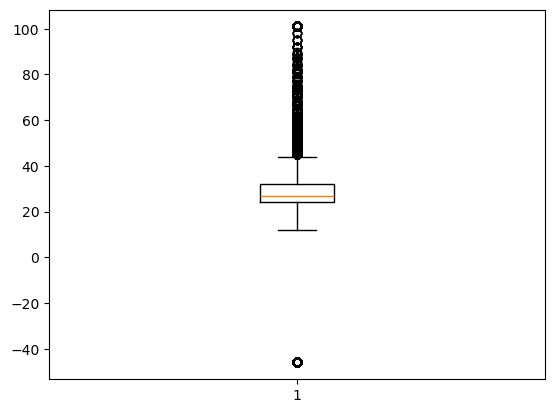

In [10]:
# check the distribution of 'BMI'
plt.boxplot(df['BMI'].dropna())

In [11]:
# calculate how many outliers in BMI
outlier_num = df[df['BMI'] >= 100]['BMI'].count() + df[df['BMI'] <= 0]['BMI'].count() 
# calculate the ratio of outliers in BMI
outlier_num / df.shape[0] * 100

3.3429385349194227

In [12]:
# delete rows with outliers
df = df[(((df['BMI'] < 100) & (df['BMI'] > 0)) | (df['BMI'].isna()))]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235474 entries, 0 to 264801
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Id                    235474 non-null  int64  
 1   BMI                   155137 non-null  float64
 2   Smoker                129449 non-null  float64
 3   HeartDiseaseorAttack  171823 non-null  float64
 4   GeneralHealth         174200 non-null  object 
 5   Mental (days)         120056 non-null  float64
 6   Sex                   174195 non-null  object 
 7   Age                   179041 non-null  float64
 8   Education             167188 non-null  object 
 9   Income                219085 non-null  object 
 10  Diabetes              235474 non-null  object 
 11  BloodPressure         195321 non-null  object 
 12  Cholesterol           200162 non-null  object 
 13  Alcoholic             186032 non-null  object 
dtypes: float64(5), int64(1), object(8)
memory usage: 26.9+ MB

### The Column of Smoker - Delete Invalid Values

In [14]:
# check weather if invalid values in Smoker
df['Smoker'].unique()

array([ nan,   1.,   0.,  11., -10.])

In [15]:
# find how many invalid values in Smoker
outlier_num = df[(df['Smoker'] > 1) | (df['Smoker'] < 0)].shape[0]
# find the proportion of invalid values
outlier_num / df.shape[0] * 100

2.7412792919812805

In [16]:
# delete invalid values in Smoker
df = df[(df['Smoker'] == 1) | (df['Smoker']== 0) | (df['Smoker'].isna())]

### The Column of Mental (days) - Delete Invalid Values

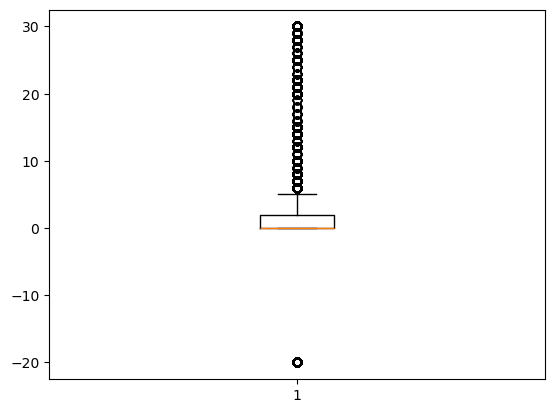

In [17]:
# check whether invalid values in Mental (days)
plt.boxplot(df['Mental (days)'].dropna())
plt.show()

In [18]:
# find how many invalid values in Mental (days)
outlier_num = df[(df['Mental (days)'] > 30) | (df['Mental (days)'] < 0)].shape[0]
# find the proportion of invalid values
outlier_num / df.shape[0] * 100

1.2697636440644664

In [19]:
# delete invalid values
df = df[(df['Mental (days)'] >= 0) & (df['Mental (days)'] <= 30) | (df['Mental (days)'].isna())]

### The Column of Age - Delete Invalid Values

In [20]:
# Check whether invalid values in Age
df['Age'].unique()

array([  63.,   54.,   nan,   74.,   66.,   62.,   59.,  278.,   67.,
         71.,   38.,   46.,   76.,   85.,   44.,   88.,   60.,   42.,
         78.,   48.,   64.,   57.,   35.,   61.,   53.,   55.,   69.,
         73.,   68.,   37.,   70.,   51.,   56.,   89.,   75.,   24.,
         49.,   80.,   58., -163.,   32.,   31.,   52.,   50.,   45.,
         43.,   90.,   77.,   22.,   65.,   84.,   79.,   47.,   27.,
         82.,   81.,   36.,   87.,   41.,   39.,   83.,   18.,   30.,
         34.,   19.,   72.,   25.,   33.,   40.,   86.,   26.,   28.,
         29.,   23.,   21.,   20.])

In [21]:
# find how many invalid values in Age
outlier_num = df[(df['Age'] == -163) | (df['Age'] == 278)].shape[0]
# find the proportion of invalid values
outlier_num / df.shape[0] * 100

3.8299773120281633

In [22]:
# delete invalid values in Smoker
df = df[(df['Age'] >= 0) & (df['Age'] <= 100) | (df['Age'].isna())]

### The column of Income - Remove Symbols, Delete Null Values, and Convert Type

In [23]:
# delete comma in Income
df['Income'] = df['Income'].str.replace(',', '')
# delete dollar symbol in Income
df['Income'] = df['Income'].str.lstrip('$')
# delete rows with null value in Income
df = df[(df['Income'].notna())]
# convert Income type to int
df['Income'] = df['Income'].astype(int)

## Fill Missing Values for Categorical Data Based on Proportion

In [24]:
# create a deep copy of data
df_imputed = df.copy()

In [25]:
# set seed to ensure reproducible
np.random.seed(7)

# Smoker column
# find distribution
proportion = df['Smoker'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['Smoker'] = df['Smoker'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['Smoker'] = df['Smoker']

# HeartDiseaseorAttack column
# find distribution
proportion = df['HeartDiseaseorAttack'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['HeartDiseaseorAttack'] = df['HeartDiseaseorAttack'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['HeartDiseaseorAttack'] = df['HeartDiseaseorAttack']

# GeneralHealth column
# find distribution
proportion = df['GeneralHealth'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['GeneralHealth'] = df['GeneralHealth'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['GeneralHealth'] = df['GeneralHealth']

# Sex column
# find distribution
proportion = df['Sex'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['Sex'] = df['Sex'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['Sex'] = df['Sex']

# Education column
# find distribution
proportion = df['Education'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['Education'] = df['Education'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['Education'] = df['Education']

# BloodPressure column
# find distribution
proportion = df['BloodPressure'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['BloodPressure'] = df['BloodPressure'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['BloodPressure'] = df['BloodPressure']

# Cholesterol column
# find distribution
proportion = df['Cholesterol'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['Cholesterol'] = df['Cholesterol'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['Cholesterol'] = df['Cholesterol']

# Alcoholic column
# find distribution
proportion = df['Alcoholic'].dropna().value_counts(normalize=True)
# fill the random choice based on proportion
df['Alcoholic'] = df['Alcoholic'].apply(lambda x: np.random.choice(proportion.index, p=proportion.values) if pd.isna(x) else x)
df_imputed['Alcoholic'] = df['Alcoholic']


## Fill Missing Values for Numeric Data by Random Forest 

### Encoding Categorical Data

#### Convert GeneralHealth to Numeric

In [26]:
# check how many levels in GeneralHealth 
df_imputed['GeneralHealth'].unique()

array(['Very Good', 'Good', 'Poor', 'Fair', 'Excellent'], dtype=object)

In [27]:
# convert GeneralHealth to numeric data
mapping = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4}
df_imputed['GeneralHealth'] = df_imputed['GeneralHealth'].map(mapping)

#### Convert Sex to Numeric

In [28]:
# check how many levels in Sex 
df_imputed['Sex'].unique()

array(['Female', 'Male'], dtype=object)

In [29]:
# convert Sex to numeric data
mapping = {'Male': 0, 'Female': 1}
df_imputed['Sex'] = df_imputed['Sex'].map(mapping)

#### Convert Education to Numeric

In [30]:
# check how many levels in Education 
df['Education'].unique()

array(['High school graduate', 'College graduate', 'Some high school',
       'Some college', 'Elementary', 'Never attended school'],
      dtype=object)

In [31]:
# convert Education to numeric data
mapping = {'Never attended school': 0, 'Elementary': 1, 'Some high school': 2, 'High school graduate': 3, 'Some college': 4, 'College graduate': 5}
df_imputed['Education'] = df_imputed['Education'].map(mapping)

#### Convert Diabetes to Numeric

In [32]:
# check how many levels in Education 
df['Diabetes'].unique()

array(['No', 'Diabetes', 'Prediabetes'], dtype=object)

In [33]:
# convert Diabetes to numeric data
mapping = {'No': 0, 'Prediabetes': 1, 'Diabetes': 2}
df_imputed['Diabetes'] = df_imputed['Diabetes'].map(mapping)

#### Convert BloodPressure to Numeric

In [34]:
# check how many levels in BloodPressure 
df['BloodPressure'].unique()

array(['Yes', 'No'], dtype=object)

In [35]:
# convert BloodPressure to numeric data
mapping = {'No': 0, 'Yes': 1}
df_imputed['BloodPressure'] = df_imputed['BloodPressure'].map(mapping)

#### Convert Cholesterol to Numeric

In [36]:
# check how many levels in Cholesterol 
df['Cholesterol'].unique()

array(['Yes', 'No'], dtype=object)

In [37]:
# convert Cholesterol to numeric data
mapping = {'No': 0, 'Yes': 1}
df_imputed['Cholesterol'] = df_imputed['Cholesterol'].map(mapping)

#### Convert Alcoholic to Numeric

In [38]:
# check how many levels in Alcoholic 
df['Alcoholic'].unique()

array(['No', 'Yes'], dtype=object)

In [39]:
# convert Alcoholic to numeric data
mapping = {'No': 0, 'Yes': 1}
df_imputed['Alcoholic'] = df_imputed['Alcoholic'].map(mapping)

### Imputing Missing Values for Numeric Data by Random Forest

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202304 entries, 0 to 264801
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Id                    202304 non-null  int64  
 1   BMI                   133191 non-null  float64
 2   Smoker                202304 non-null  float64
 3   HeartDiseaseorAttack  202304 non-null  float64
 4   GeneralHealth         202304 non-null  object 
 5   Mental (days)         101868 non-null  float64
 6   Sex                   202304 non-null  object 
 7   Age                   151957 non-null  float64
 8   Education             202304 non-null  object 
 9   Income                202304 non-null  int64  
 10  Diabetes              202304 non-null  object 
 11  BloodPressure         202304 non-null  object 
 12  Cholesterol           202304 non-null  object 
 13  Alcoholic             202304 non-null  object 
dtypes: float64(5), int64(2), object(7)
memory usage: 23.2+ MB

In [41]:
# create a iterative imputer to execute RandomForestRegressor method with a maximum of five iterations
# random_state=42 makes the result is the same every time, which ensures reproducibility
imp = IterativeImputer(estimator=RandomForestRegressor(), max_iter=5, random_state=42)

# fit the data by random forest to impute missing values
df_imputed_rf = imp.fit_transform(df_imputed)

# Convert back to a DataFrame
df_imputed_rf = pd.DataFrame(df_imputed_rf, columns=df_imputed.columns)

print(df_imputed_rf)

              Id    BMI  Smoker  HeartDiseaseorAttack  GeneralHealth  \
0            0.0  40.00     0.0                   0.0            3.0   
1            1.0  25.00     1.0                   0.0            2.0   
2            2.0  33.58     0.0                   0.0            0.0   
3            3.0  27.00     1.0                   0.0            2.0   
4            4.0  24.00     1.0                   0.0            3.0   
...          ...    ...     ...                   ...            ...   
202299  264796.0  22.00     0.0                   0.0            4.0   
202300  264797.0  28.00     1.0                   0.0            4.0   
202301  264798.0  27.00     0.0                   0.0            2.0   
202302  264800.0  23.00     0.0                   0.0            3.0   
202303  264801.0  37.00     0.0                   0.0            2.0   

        Mental (days)  Sex    Age  Education   Income  Diabetes  \
0               10.81  1.0  63.00        3.0  73106.0       0.0   
1

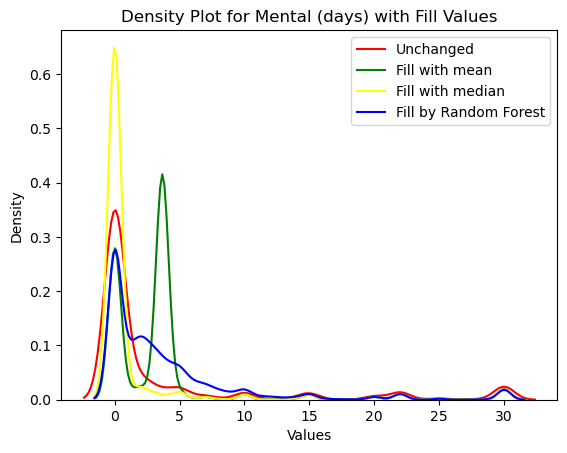

In [42]:
# fill null value with median
new_mental_median = df['Mental (days)'].fillna(df['Mental (days)'].dropna().median())
# fill null value with mean
new_mental_mean = df['Mental (days)'].fillna(df['Mental (days)'].dropna().mean())

# plot kernel density estimation of each filling
sns.kdeplot(df['Mental (days)'], label='Unchanged', color='red')
sns.kdeplot(new_mental_mean, label='Fill with mean', color='green')
sns.kdeplot(new_mental_median, label='Fill with median', color='yellow')
sns.kdeplot(df_imputed_rf['Mental (days)'], label='Fill by Random Forest', color='blue')

# add title, labels and legend to plot
plt.title('Density Plot for Mental (days) with Fill Values')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend()
plt.show()

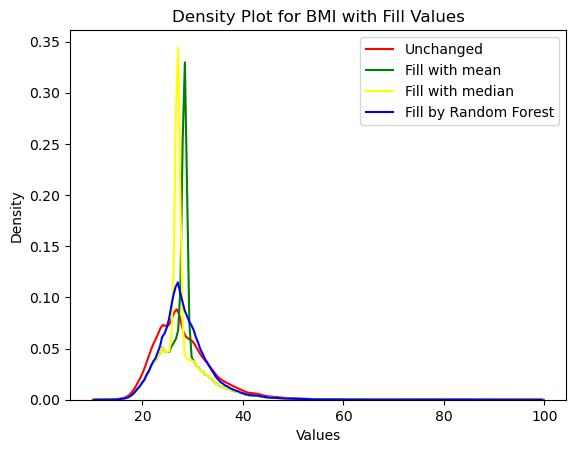

In [43]:
# fill null value by mean
new_bmi_mean = df['BMI'].fillna(df['BMI'].dropna().mean())
# fill null value with median
new_bmi_median = df['BMI'].fillna(df['BMI'].dropna().median())

sns.kdeplot(df['BMI'], label='Unchanged', color='red')
sns.kdeplot(new_bmi_mean, label='Fill with mean', color='green')
sns.kdeplot(new_bmi_median, label='Fill with median', color='yellow')
sns.kdeplot(df_imputed_rf['BMI'], label='Fill by Random Forest', color='blue')

plt.title('Density Plot for BMI with Fill Values')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend()
plt.show()

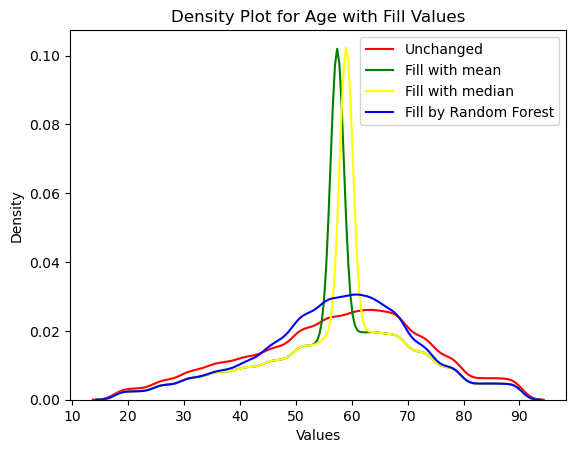

In [44]:
# fill null value with median
new_age_median = df['Age'].fillna(df['Age'].dropna().median())
# fill null value with mean
new_age_mean = df['Age'].fillna(df['Age'].dropna().mean())

sns.kdeplot(df['Age'], label='Unchanged', color='red')
sns.kdeplot(new_age_mean, label='Fill with mean', color='green')
sns.kdeplot(new_age_median, label='Fill with median', color='yellow')
sns.kdeplot(df_imputed_rf['Age'], label='Fill by Random Forest', color='blue')

plt.title('Density Plot for Age with Fill Values')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend()
plt.show()

In [45]:
# Write the filled columns back to the original data
df['BMI'] = df_imputed_rf['BMI'].values
df['Mental (days)'] = df_imputed_rf['Mental (days)'].values
df['Age'] = df_imputed_rf['Age'].values

## Unifing Semantic Representation of Categorical Data

In [46]:
mapping = {0:'No', 1:'Yes'}

df['Smoker'] = df['Smoker'].map(mapping)
df['HeartDiseaseorAttack'] = df['HeartDiseaseorAttack'].map(mapping)

## Write dataset to csv file 

In [47]:
# write to csv file with name xiwu3008_A1_CleanDataset.csv
df.to_csv('xiwu3008_A1_CleanDataset.csv', index=False)

# Exploratory data analysis (EDA)

### Research 1 - Does smoking increase the risk of diabetes for different age groups?

In [48]:
# convert 'Diabetes' and 'Prediabetes' to 1, and 'No' to 0, so that to help calculate the percentage of  diabetes and prediabetes
mapping = {'No':0, 'Diabetes':1, 'Prediabetes':1}
dia = df['Diabetes'].map(mapping).astype(int)

# define the bins and labels for grouping Age
bin = [0, 21, 41, 61, 81, float('inf')]  
label = ['[0,21)', '[21-41)', '[41-60)', '[61-81)', '[81,inf)']
# cut the age by the bins with labels
age_group = pd.cut(df['Age'], bins=bin, labels=label, right=False)

# combine the encoding Diabetes and Smoker to a Dataframe
df_analysis_1 = pd.DataFrame([df['Smoker'], df['Alcoholic'], age_group, dia]).T

# calculate the diabetes rate grouped by age and smoker and 
group_age_smoker = df_analysis_1.groupby(['Age', 'Smoker'])['Diabetes'].mean().reset_index()

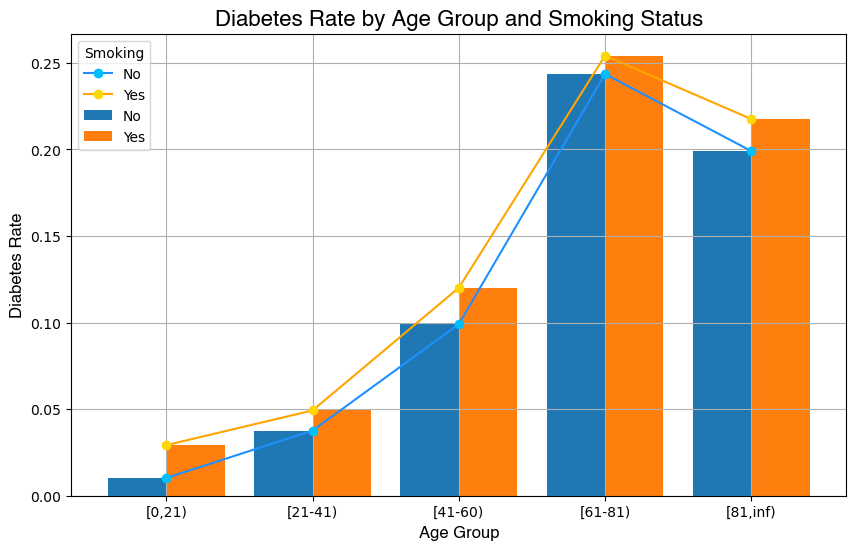

In [49]:
# divide data by smoke status
smoke = group_age_smoker[group_age_smoker['Smoker'] == 'Yes']
no_smoke = group_age_smoker[group_age_smoker['Smoker'] == 'No']

order = ['[0,21)', '[21-41)', '[41-60)', '[61-81)', '[81,inf)']
# Pivot the data to have age_group as index and smoker as columns
diabetes_pivot = group_age_smoker.pivot(index='Age', columns='Smoker', values='Diabetes')
# diabetes_pivot = diabetes_pivot.reindex(label)

# Plotting as a bar chart
diabetes_pivot.plot(kind='bar', figsize=(10, 6), width=0.8, legend='Smoking')


# line plot of diabetes rate by age droup and smoker status
plt.plot(no_smoke['Age'], no_smoke['Diabetes'], label='No', marker='o', color='dodgerblue', mec = 'deepskyblue', mfc = 'deepskyblue')
plt.plot(smoke['Age'], smoke['Diabetes'], label='Yes', marker='o', color='orange', mec = 'gold', mfc = 'gold')

# define a font
hfont = {'fontname':'Helvetica'}

# set title, labels and legend with cuatomized font and size
plt.title('Diabetes Rate by Age Group and Smoking Status', **hfont, fontsize=16)
plt.xlabel('Age Group', **hfont, fontsize=12)
plt.ylabel('Diabetes Rate', **hfont, fontsize=12)
plt.legend(title='Smoking', fontsize=10)

# adjust x ticks 
plt.xticks(rotation=0)

# set grid
plt.grid(True)

# set style
plt.style.use('default')
plt.show()

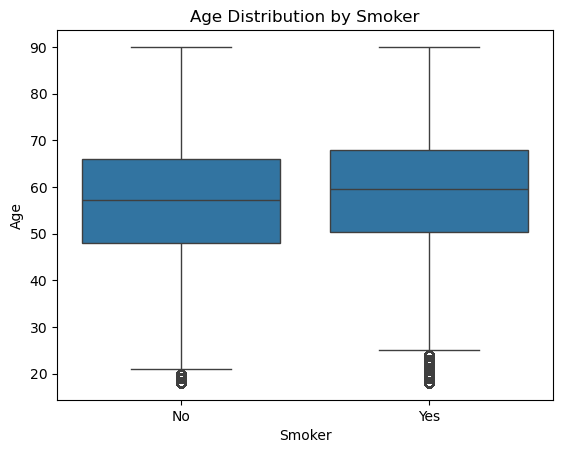

In [50]:
sns.boxplot(x="Smoker", y="Age", data=df)

# Add labels and title
plt.xlabel("Smoker")
plt.ylabel("Age")
plt.title("Age Distribution by Smoker")

# Show the plot
plt.show()

In [51]:
# a new dataframe used to calculate VIF
df_vif = df[['Age', 'Smoker']]

# map Smoker to numeric
df_vif['Smoker'] = df['Smoker'].map({'Yes': 1, 'No': 0})

# add constant as intercept term
df_encoded = add_constant(df_vif[['Age', 'Smoker']])

# compute VIF for each feature
vif_result = pd.DataFrame()
vif_result['Variable'] = df_encoded.columns
vif_result['VIF'] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]

# calculate Spearman correlation
spearman_corr, spearman_pval = spearmanr(df['Age'], df['Smoker'])

# print the VIF and Spearman correlation 
print(vif_result)
print(f'Spearman Correlation: {spearman_corr}, p-value is smaller than 0.05: {spearman_pval < 0.05}')

/var/folders/x7/q_ttjngx4h53vj1h142zkj7r0000gn/T/ipykernel_53246/1261603553.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vif['Smoker'] = df['Smoker'].map({'Yes': 1, 'No': 0})


  Variable        VIF
0    const  17.757457
1      Age   1.004518
2   Smoker   1.004518
Spearman Correlation: 0.07101531091531604, p-value is smaller than 0.05: True


### Research 2 - Does a high BMI mean a greater risk of high cholesterol and high blood pressure in adults?

In [52]:
# only consider adults, so delete age < 18
df_analysis_2 = df[df['Age'] >= 18]

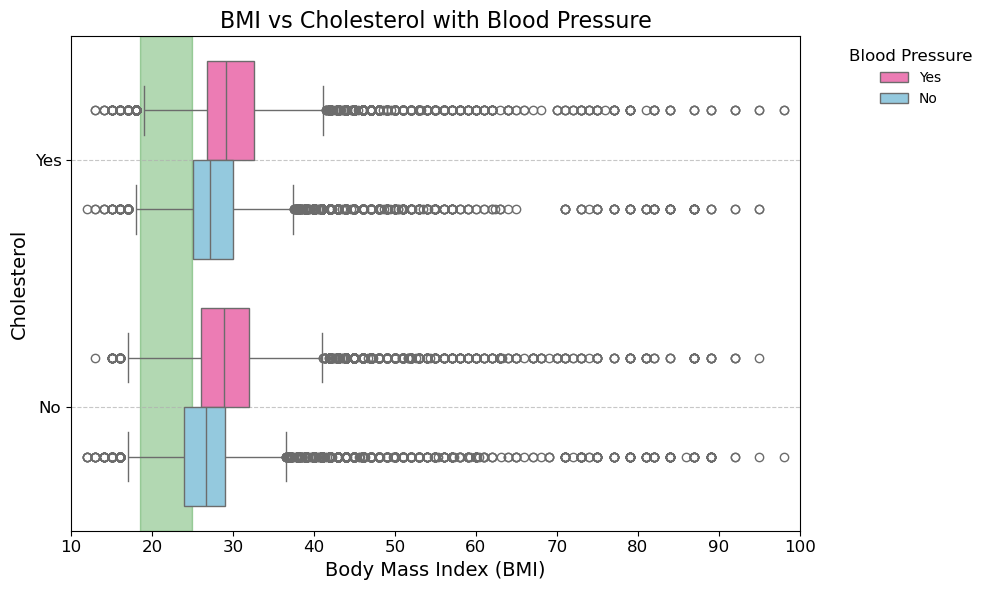

In [53]:
# set figure size
plt.figure(figsize=(10, 6))

# boxplot of BMI vs Chplesterol, and colored by BloodPressure
sns.boxplot(data=df_analysis_2, x="BMI", y="Cholesterol", hue="BloodPressure", palette = ['#FF69B4', '#87CEEB'])
# palette = ['#FF69B4', '#87CEEB', '#32CD32', '#FF6347', '#FFD700']

# set the x-axis range from 10 to 100
plt.xlim(10, 100)  

# set title and labels with customized font size
plt.title('BMI vs Cholesterol with Blood Pressure', fontsize=16)
plt.xlabel('Body Mass Index (BMI)', fontsize=14)
plt.ylabel('Cholesterol', fontsize=14)

# move the legend outside the plot using bbox_to_anchor
plt.legend(title='Blood Pressure', loc='upper left', fontsize=10, title_fontsize=12, 
           bbox_to_anchor=(1.05, 1), frameon=False)

# customize size of x and y tick labels
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)

# add grid with customized settings
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# add a shaded region for BMI (18.5 to 24.99), which is normal BMI value
plt.axvspan(18.5, 24.99, color='green', alpha=0.3)

# Show the plot
plt.tight_layout()  # Automatically adjusts subplots to fit into the figure area
plt.show()

# 18.50 - 24.99

In [54]:
# set outlier boundary
lower_bound = 16.5
upper_bound = 50

# delete outliers
df_clean = df_analysis_2[(df_analysis_2['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)]

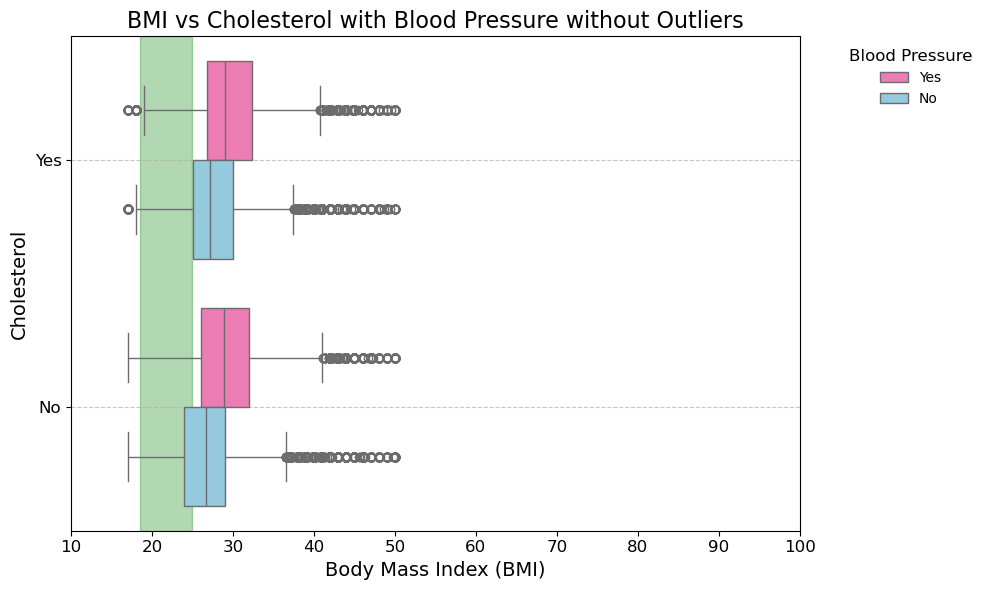

In [55]:
# set figure size
plt.figure(figsize=(10, 6))

# boxplot of BMI vs Chplesterol, and colored by BloodPressure
sns.boxplot(data=df_clean, x="BMI", y="Cholesterol", hue="BloodPressure", palette = ['#FF69B4', '#87CEEB'])
# palette = ['#FF69B4', '#87CEEB', '#32CD32', '#FF6347', '#FFD700']

# set the x-axis range from 10 to 100
plt.xlim(10, 100)  

# set title and labels with customized font size
plt.title('BMI vs Cholesterol with Blood Pressure without Outliers', fontsize=16)
plt.xlabel('Body Mass Index (BMI)', fontsize=14)
plt.ylabel('Cholesterol', fontsize=14)

# move the legend outside the plot using bbox_to_anchor
plt.legend(title='Blood Pressure', loc='upper left', fontsize=10, title_fontsize=12, 
           bbox_to_anchor=(1.05, 1), frameon=False)

# customize size of x and y tick labels
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)

# add grid with customized settings
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# add a shaded region for BMI (18.5 to 24.99), which is normal BMI value
plt.axvspan(18.5, 24.99, color='green', alpha=0.3)

# Show the plot
plt.tight_layout()  # Automatically adjusts subplots to fit into the figure area
plt.show()

# 18.50 - 24.99

In [56]:
# a new dataframe used to calculate VIF
df_vif = df[['BMI', 'Cholesterol', 'BloodPressure']]

# map Smoker to numeric
df_vif['Cholesterol'] = df['Cholesterol'].map({'Yes': 1, 'No': 0})
df_vif['BloodPressure'] = df['BloodPressure'].map({'Yes': 1, 'No': 0})

# add constant as intercept term
df_encoded = add_constant(df_vif[['BMI', 'Cholesterol', 'BloodPressure']])

# create a datafrane with name of columns as the values of Variable
vif_result = pd.DataFrame()
vif_result['Variable'] = df_encoded.columns

# compute VIF for each feature pairwise
vif_result['VIF'] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]

# create a dataframe store the spearman correlation and p-value, 
# the index and columns is name of columns in df_vif
corr_matrix = pd.DataFrame(index=df_vif.columns, columns=df_vif.columns)
p_value_matrix = pd.DataFrame(index=df_vif.columns, columns=df_vif.columns)

# compute spearmanr corr and p-value pariwise
for col1 in df_vif.columns:
    for col2 in df_vif.columns:
        corr, p_value = spearmanr(df_vif[col1], df_vif[col2])
        corr_matrix.loc[col1, col2] = corr
        p_value_matrix.loc[col1, col2] = (p_value < 0.05)

print("VIF:")
print(vif_result)

print("\nSpearman Correlation:")
print(corr_matrix)

print("\nP-Value:")
print(p_value_matrix)

/var/folders/x7/q_ttjngx4h53vj1h142zkj7r0000gn/T/ipykernel_53246/98182837.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vif['Cholesterol'] = df['Cholesterol'].map({'Yes': 1, 'No': 0})
/var/folders/x7/q_ttjngx4h53vj1h142zkj7r0000gn/T/ipykernel_53246/98182837.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vif['BloodPressure'] = df['BloodPressure'].map({'Yes': 1, 'No': 0})


VIF:
        Variable        VIF
0          const  26.479167
1            BMI   1.049706
2    Cholesterol   1.049854
3  BloodPressure   1.084889

Spearman Correlation:
                    BMI Cholesterol BloodPressure
BMI                 1.0    0.134542      0.247191
Cholesterol    0.134542         1.0      0.208199
BloodPressure  0.247191    0.208199           1.0

P-Value:
                BMI Cholesterol BloodPressure
BMI            True        True          True
Cholesterol    True        True          True
BloodPressure  True        True          True
